In [1]:
import os
import pickle
from typing import Tuple,Union
import collections
import random
import copy

import numpy as np
import gymnasium as gym
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
class Offline_Buffer():
    def __init__(self,
                 capacity:int,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
         
    def to_tensor(self) -> None:
        obs, action, reward, next_obs, done = zip(*self.buffer)
        self.obs = torch.tensor(np.array(obs),dtype=torch.float32,device=self.device)
        self.action = torch.tensor(np.array(action),dtype=torch.int64,device=self.device).unsqueeze(-1)
        self.reward = torch.tensor(np.array(reward),dtype=torch.float32,device=self.device).unsqueeze(-1)
        self.next_obs = torch.tensor(np.array(next_obs),dtype=torch.float32,device=self.device)
        self.done = torch.tensor(np.array(done),dtype=torch.float32,device=self.device).unsqueeze(-1)
        
    def sample(self,batch_size:int) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        idx = np.random.choice(len(self.obs),batch_size)
         
        return self.obs[idx],self.action[idx],self.reward[idx],self.next_obs[idx],self.done[idx]
    
    def __len__(self) -> int:
        return len(self.buffer)
    
    def save_to_disk(self, filename:str) -> None:
        os.makedirs(os.path.dirname(filename), exist_ok=True)
        with open(filename, 'wb') as f:
            pickle.dump(self.buffer, f)
    
    def load_from_disk(self, filename:str) -> None:
        with open(filename, 'rb') as f:
            self.buffer = pickle.load(f)
        self.to_tensor()


class BCQ_Agent():
    '''Supervised Learning + DQN(no interaction)'''
    def __init__(self,
                 buffer:Offline_Buffer,
                 Q_network:torch.nn.Module,
                 Q_optimizer:torch.optim.Optimizer,
                 G_network:torch.nn.Module,
                 G_optimizer:torch.optim.Optimizer,
                 threshold:float = 0.3,
                 gamma:float = 0.9,
                 batch_size:int = 32,
                 target_sync_frequent:int = 4, # The frequency of synchronizing the parameters of the two Q networks
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.buffer = buffer
        self.batch_size = batch_size
        self.device = device
        
        self.threshold = threshold
        self.Q_network = Q_network
        self.target_Q_network = copy.deepcopy(Q_network).to(self.device)        
        self.Q_optimizer = Q_optimizer
        
        self.G_network = G_network
        self.G_optimizer = G_optimizer
        self.gamma = gamma
        self.target_sync_frequent = target_sync_frequent
        
        self.exp_counter = 0
        
    def get_action(self,obs:Union[np.ndarray,torch.Tensor]) -> Union[int,torch.Tensor]:
        '''
        Choose an action with the highest Q value
        '''
        behav_flag = False
        if not isinstance(obs,torch.Tensor):
            behav_flag = True
            obs = torch.tensor(obs,dtype=torch.float32).to(self.device)
        q_table = self.Q_network(obs)
        dists = self.G_network(obs)
        # print(dists.shape)
        mask = (dists/dists.max(-1,keepdim=True)[0] >= self.threshold).float()
        action = (mask*q_table + (1-mask)*(-1e8)).argmax(-1)
        if behav_flag:
            action = int(action.item())
        
        return action
                    
    def batch_train(self,
                        obs:torch.Tensor,
                        action:torch.Tensor,
                        reward:torch.Tensor,
                        next_obs:torch.Tensor,
                        done:torch.Tensor) -> None:
        
        self.batch_Q_approximation(obs,action,reward,next_obs,done)
        self.batch_actor_update(obs) # train actor

    
    def batch_Q_approximation(self,
                              obs:torch.Tensor,
                              action:torch.Tensor,
                              reward:torch.Tensor,
                              next_obs:torch.Tensor,
                              done:torch.Tensor) -> None:
        """To update the main critic network"""
        current_Q = torch.gather(self.Q_network(obs),1,action)
        next_action = self.get_action(next_obs).unsqueeze(-1)
        target_Q = reward + (1-done) * self.gamma * torch.gather(self.target_Q_network(next_obs),-1,next_action)
        
        td_loss = F.mse_loss(current_Q,target_Q.detach())

        # BESE loss + L2 regularization
        g_loss = torch.mean(-torch.log(self.G_network(obs).gather(1, action))) + 1e-2 * self.G_network(obs).pow(2).mean()
        
        self.Q_optimizer.zero_grad()
        td_loss.backward()
        self.Q_optimizer.step()
        
        self.G_optimizer.zero_grad()
        g_loss.backward()
        self.G_optimizer.step()
        
    def Q_approximation(self):
        self.exp_counter += 1
        self.batch_Q_approximation(*self.buffer.sample(self.batch_size))
        if self.exp_counter % self.target_sync_frequent == 0:
            self.sync_target_Q_network()
            
    def sync_target_Q_network(self) -> None:
        for target_params, main_params in zip(self.target_Q_network.parameters(), self.Q_network.parameters()):
            target_params.data.copy_(main_params.data)
        

In [3]:
class G_Network(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(G_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.relu(x)
        return torch.softmax(self.fc2(x), dim=-1)


class Q_Network(torch.nn.Module):
    def __init__(self,
                 obs_dim:int,
                 action_dim:int,
                 hidden_size:int=64) -> None:
        super(Q_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
                
        return x

In [4]:
class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 epoch_num:int = 1000,
                 test_iters:int = 10,
                 q_lr:float = 1e-3,
                 g_lr:float = 1e-3,
                 gamma:float = 0.95,
                 buffer_capacity:int = 2000,
                 target_sync_frequent:int = 4,
                 batch_size:int = 32,
                 seed:int = 100,
                 buffer_load_path:str = "../Data/CartPole_PPO_OfflineBuffer.pkl",
                 my_device:str = "cpu"
                 ) -> None:
        
        self.seed = seed
        random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(my_device)
        
        self.eval_env = env
        _ = self.eval_env.reset(seed=self.seed)
        self.epoch_num = epoch_num
        self.test_iters = test_iters
        obs_dim = gym.spaces.utils.flatdim(env.observation_space)
        action_dim = gym.spaces.utils.flatdim(env.action_space)
                
        buffer = Offline_Buffer(capacity=buffer_capacity,
                                     device=self.device)
        # Load trajectory data from disk
        print("Load trajectory data from disk...")
        buffer.load_from_disk(buffer_load_path)
        print("Trajectory data loaded.")
        
        Q_network = Q_Network(obs_dim,action_dim).to(self.device)
        Q_optimizer = torch.optim.Adam(Q_network.parameters(),lr=q_lr)
        G_network = G_Network(obs_dim,action_dim).to(self.device)
        G_optimizer = torch.optim.Adam(G_network.parameters(),lr=g_lr)
                
        self.agent = BCQ_Agent(buffer=buffer,
                              Q_network=Q_network,
                              Q_optimizer=Q_optimizer,
                              G_network=G_network,
                              G_optimizer=G_optimizer,
                              gamma=gamma,
                              batch_size=batch_size,
                              target_sync_frequent=target_sync_frequent,
                              device=self.device)
                
        self.test_rewards = []
        
    def train(self) -> None:
        # Batch training
        with tqdm(total=self.epoch_num, desc='Training') as pbar:
            for _ in range(self.epoch_num):
                self.train_epoch()
                avg_reward = self.test()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1)
    
    def train_epoch(self) -> None:
        self.agent.Q_approximation()
        
    def test(self) -> list:
        epoch_test_rewards = []
        for _ in range(self.test_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            epoch_test_rewards.append(episode_reward)
            pass
        self.test_rewards.append(epoch_test_rewards)
        
        return np.mean(epoch_test_rewards)

In [5]:
'''
Data used: PPO - Bad:Avergae:Good = 5:4:1  --  20 episodes ~= 4000 steps
Sourced from 180-episode trained PPO agent
'''
eval_env = gym.make("CartPole-v0")
Manager = TrainManager(env=eval_env,
                          epoch_num=2500,
                          test_iters=10,
                          q_lr=1e-3,
                          g_lr=1e-3,
                          gamma=0.95,
                          buffer_capacity=5000,
                          target_sync_frequent=4,
                          batch_size=64,
                          seed=100,
                          buffer_load_path="../Data/CartPole_PPO_OfflineBuffer_poor.pkl",
                          my_device="cpu")
Manager.train()
poor_rewards = np.array(Manager.test_rewards)

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 2500/2500 [10:21<00:00,  4.03it/s, Avg. Test Reward=200] 


In [6]:
'''
Data used: PPO - Bad:Avergae:Good = 2:5:3  --  20 episodes ~= 4000 steps
Sourced from 180-episode trained PPO agent
'''
eval_env = gym.make("CartPole-v0")
Manager = TrainManager(env=eval_env,
                          epoch_num=2500,
                          test_iters=10,
                          q_lr=1e-3,
                          g_lr=1e-3,
                          gamma=0.95,
                          buffer_capacity=5000,
                          target_sync_frequent=4,
                          batch_size=64,
                          seed=100,
                          buffer_load_path="../Data/CartPole_PPO_OfflineBuffer.pkl",
                          my_device="cpu")
Manager.train()
rewards = np.array(Manager.test_rewards)

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 2500/2500 [10:04<00:00,  4.13it/s, Avg. Test Reward=200] 


In [7]:
'''
Data used: PPO - Bad:Avergae:Good = 1:3:6  --  20 episodes ~= 4000 steps
Sourced from 180-episode trained PPO agent
'''
eval_env = gym.make("CartPole-v0")
Manager = TrainManager(env=eval_env,
                          epoch_num=2500,
                          test_iters=10,
                          q_lr=1e-3,
                          g_lr=1e-3,
                          gamma=0.95,
                          buffer_capacity=5000,
                          target_sync_frequent=4,
                          batch_size=64,
                          seed=100,
                          buffer_load_path="../Data/CartPole_PPO_OfflineBuffer_good.pkl",
                          my_device="cpu")
Manager.train()
good_rewards = np.array(Manager.test_rewards)

Load trajectory data from disk...
Trajectory data loaded.


Training: 100%|██████████| 2500/2500 [09:35<00:00,  4.35it/s, Avg. Test Reward=200] 


In [8]:
'''
Evaluating PPO Benchmark
'''
# Pre-trained actor
class PPO_Actor(torch.nn.Module):
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(PPO_Actor, self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
                    
    def forward(self,x:torch.Tensor) -> int:
        x = torch.tensor(x, dtype = torch.float32)
        x = F.relu(self.fc1(x))
        dist = self.fc2(x)
        dist = F.softmax(dist, dim = 0) 
        action_probs = torch.distributions.Categorical(dist)
        picked_action = action_probs.sample()
                
        return picked_action.item()

def eval_policy(env: gym.Env, 
         actor: torch.nn.Module,
         eval_episodes: int = 1000,
         eval_iters: int = 10,
         seed: int = 100
         ) -> list:
     _ = env.reset(seed=seed)
     random.seed(seed)
     torch.manual_seed(seed)
     torch.cuda.manual_seed_all(seed)
     np.random.seed(seed)
     torch.backends.cudnn.deterministic = True
     test_returns = []
     
     with tqdm(total=eval_episodes, desc='Benchmark Evaluation', unit='episodes') as pbar:
          for _ in range(eval_episodes):
              episode_returns = []
              for _ in range(eval_iters):
                  done = False
                  obs,_ = env.reset()
                  episode_return = 0               
                  while not done:
                      action = actor(obs)
                      next_state, reward, terminated, truncated, _ = env.step(action)
                      done = terminated or truncated
                      episode_return += reward
                      obs = next_state
                      pass
                  episode_returns.append(episode_return)
                  pass
              test_returns.append(episode_returns)
              pbar.update(1)
            
     return test_returns

In [9]:
eval_env = gym.make("CartPole-v0")
obs_dim = gym.spaces.utils.flatdim(eval_env.observation_space)
action_dim = gym.spaces.utils.flatdim(eval_env.action_space)
ppo_actor = PPO_Actor(obs_dim,action_dim,hidden_size=64)
ppo_actor.load_state_dict(torch.load('../Models/CartPole_PPO180_Actor.pth'))
ppo_benchmark_returns = eval_policy(eval_env,ppo_actor,eval_episodes=2500,eval_iters=10,seed=100)

Benchmark Evaluation: 100%|██████████| 2500/2500 [16:10<00:00,  2.58episodes/s]


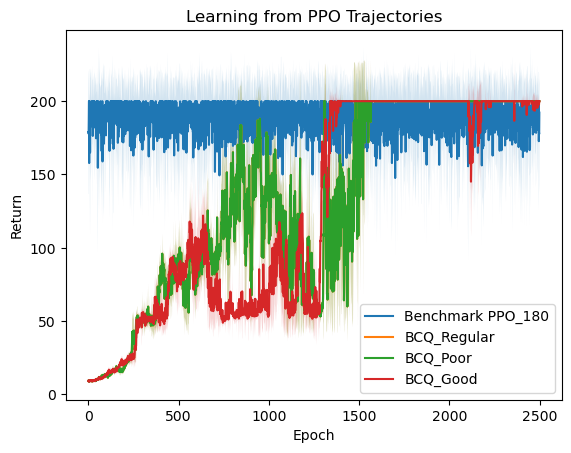

In [18]:
'''
Plotting
'''
means = np.mean(rewards,axis=-1)
stds = np.std(rewards,axis=-1)
means_poor = np.mean(poor_rewards,axis=-1)
stds_poor = np.std(poor_rewards,axis=-1)
means_good = np.mean(good_rewards,axis=-1)
stds_good = np.std(good_rewards,axis=-1)
Benchmark_PPO_means = np.mean(ppo_benchmark_returns,axis=-1)
Benchmark_PPO_stds = np.std(ppo_benchmark_returns,axis=-1)

plt.plot(Benchmark_PPO_means,label="Benchmark PPO_180")
plt.plot(means,label="BCQ_Regular")
plt.plot(means_poor,label="BCQ_Poor")
plt.plot(means_good,label="BCQ_Good")
plt.fill_between(np.arange(len(Benchmark_PPO_means)), Benchmark_PPO_means-Benchmark_PPO_stds, Benchmark_PPO_means+Benchmark_PPO_stds, alpha=0.2)
plt.fill_between(np.arange(len(means)), means-stds, means+stds, alpha=0.2)
plt.fill_between(np.arange(len(means_poor)), means_poor-stds_poor, means_poor+stds_poor, alpha=0.2)
plt.fill_between(np.arange(len(means_good)), means_good-stds_good, means_good+stds_good, alpha=0.2)

plt.xlabel("Epoch")
plt.ylabel("Return")
plt.title('Learning from PPO Trajectories')
plt.legend()
plt.show()   